In [1]:
# Cell 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import spacy
from transformers import pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [3]:
# Cell 2: Load and Inspect Data
# Load the cleaned data from Task 1 with correct Windows path
data = pd.read_csv("D:/Personal/KAIM-10 Academy/Week 2/Project Work/Customer_Exp_Analytics_Fintech Apps/data/processed/bank_reviews_cleaned.csv")

print("=== DATA OVERVIEW ===")
print(f"📊 Total reviews: {data.shape[0]}")
print(f"📋 Columns: {data.columns.tolist()}")

print("\n🔍 First 5 rows:")
print(data.head())

print(f"\n🏦 Bank Distribution:")
print(data['bank'].value_counts())

print(f"\n⭐ Rating Distribution:")
print(data['rating'].value_counts().sort_index())

print(f"\n📅 Date Range:")
print(f"From: {data['date'].min()} To: {data['date'].max()}")

print(f"\n🔍 Missing Values:")
print(data.isnull().sum())

=== DATA OVERVIEW ===
📊 Total reviews: 1200
📋 Columns: ['review', 'rating', 'date', 'bank', 'source', 'review_id', 'user_name', 'thumbs_up', 'text_length', 'word_count', 'app_version']

🔍 First 5 rows:
                                              review  rating        date  \
0                                          very good       5  2025-11-25   
1           most of the time is not working properly       1  2025-11-25   
2                                       good service       5  2025-11-25   
3                                     not use for me       3  2025-11-23   
4  It keeps notifying me to disable developer opt...       1  2025-11-22   

                bank       source                             review_id  \
0  Bank of Abyssinia  Google Play  7ef21cf6-d226-4370-ab96-01c909dbc58d   
1  Bank of Abyssinia  Google Play  896ee9aa-a483-4b1f-b73c-0a26c4b54790   
2  Bank of Abyssinia  Google Play  15c3586b-e672-48db-b3c0-09508375763f   
3  Bank of Abyssinia  Google Play  6f7113

In [4]:
# Cell 3: Initialize NLP Models
print("🚀 Initializing NLP Models...")

try:
    # Initialize sentiment analyzer
    sentiment_analyzer = pipeline(
        "sentiment-analysis",
        model="distilbert-base-uncased-finetuned-sst-2-english",
        max_length=512,
        truncation=True
    )
    print("✅ Sentiment analyzer loaded successfully!")
    
    # Load spaCy for thematic analysis
    nlp = spacy.load("en_core_web_sm")
    print("✅ spaCy model loaded successfully!")
    
except Exception as e:
    print(f"❌ Error loading models: {e}")
    print("Please make sure you installed all requirements:")
    print("pip install transformers torch spacy")
    print("python -m spacy download en_core_web_sm")

🚀 Initializing NLP Models...


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

Device set to use cpu


✅ Sentiment analyzer loaded successfully!
✅ spaCy model loaded successfully!


In [5]:
# Cell 4: Sentiment Analysis Function
def analyze_sentiment_distilbert(text):
    """
    Analyze sentiment using DistilBERT with neutral category
    """
    if pd.isna(text) or str(text).strip() == "":
        return 'NEUTRAL', 0.5
    
    try:
        result = sentiment_analyzer(str(text))[0]
        label = result['label']
        score = result['score']
        
        # Add neutral category for low confidence
        if score < 0.75:
            return 'NEUTRAL', score
        else:
            return label.upper(), score
            
    except Exception as e:
        print(f"Error analyzing text: {e}")
        return 'NEUTRAL', 0.5

# Test the function
test_texts = [
    "I love this banking app! It's very fast and reliable.",
    "This app keeps crashing during money transfers, very frustrating.",
    "The interface is okay but could be better.",
    "very good",  # Like your actual short reviews
    "not use for me"  # Another actual review
]

print("🧪 Testing Sentiment Analysis:")
for text in test_texts:
    sentiment, score = analyze_sentiment_distilbert(text)
    print(f"Text: {text[:50]}... → Sentiment: {sentiment}, Score: {score:.3f}")

🧪 Testing Sentiment Analysis:
Text: I love this banking app! It's very fast and reliab... → Sentiment: POSITIVE, Score: 1.000
Text: This app keeps crashing during money transfers, ve... → Sentiment: NEGATIVE, Score: 0.999
Text: The interface is okay but could be better.... → Sentiment: NEGATIVE, Score: 0.927
Text: very good... → Sentiment: POSITIVE, Score: 1.000
Text: not use for me... → Sentiment: NEGATIVE, Score: 0.995


    Sentiment Analysis:

In [8]:
# Cell 5: Sentiment Analysis for all reveiw
print("🎯 Applying Sentiment Analysis to ALL Reviews...")

# Use the entire dataset - no sampling!
sample_data = data.copy()  # This is all 1200 reviews

print(f"Analyzing sentiment for ALL {len(sample_data)} reviews...")
print(f"Bank distribution:")
print(sample_data['bank'].value_counts())

# Apply sentiment analysis to ALL reviews
print("This will take a few minutes for 1200 reviews...")

# Process in batches to monitor progress
batch_size = 50
total_batches = (len(sample_data) + batch_size - 1) // batch_size

sentiment_labels = []
sentiment_scores = []

for i in range(0, len(sample_data), batch_size):
    batch_end = min(i + batch_size, len(sample_data))
    batch_reviews = sample_data['review'].iloc[i:batch_end].tolist()
    
    # Analyze batch
    for review in batch_reviews:
        sentiment, score = analyze_sentiment_distilbert(review)
        sentiment_labels.append(sentiment)
        sentiment_scores.append(score)
    
    # Progress update
    batch_num = (i // batch_size) + 1
    if batch_num % 5 == 0 or batch_num == total_batches:
        print(f"  Processed batch {batch_num}/{total_batches} ({batch_end}/{len(sample_data)} reviews)")

# Add results to dataframe
sample_data['sentiment_label'] = sentiment_labels
sample_data['sentiment_score'] = sentiment_scores

print("✅ Sentiment analysis completed for ALL reviews!")
print(f"\n📊 Overall Sentiment Distribution:")
print(sample_data['sentiment_label'].value_counts())

print(f"\n🏦 Sentiment by Bank:")
sentiment_by_bank = sample_data.groupby(['bank', 'sentiment_label']).size().unstack(fill_value=0)
print(sentiment_by_bank)

🎯 Applying Sentiment Analysis to ALL Reviews...
Analyzing sentiment for ALL 1200 reviews...
Bank distribution:
bank
Bank of Abyssinia              400
Commercial Bank of Ethiopia    400
Dashen Bank                    400
Name: count, dtype: int64
This will take a few minutes for 1200 reviews...
  Processed batch 5/24 (250/1200 reviews)
  Processed batch 10/24 (500/1200 reviews)
  Processed batch 15/24 (750/1200 reviews)
  Processed batch 20/24 (1000/1200 reviews)
  Processed batch 24/24 (1200/1200 reviews)
✅ Sentiment analysis completed for ALL reviews!

📊 Overall Sentiment Distribution:
sentiment_label
POSITIVE    682
NEGATIVE    446
NEUTRAL      72
Name: count, dtype: int64

🏦 Sentiment by Bank:
sentiment_label              NEGATIVE  NEUTRAL  POSITIVE
bank                                                    
Bank of Abyssinia                 189       34       177
Commercial Bank of Ethiopia       127       20       253
Dashen Bank                       130       18       252


In [9]:
# Cell 6: Sentiment Aggregation by Bank and Rating
print("📊 GENERATING SENTIMENT AGGREGATIONS")

# 1. Sentiment by Bank (with more detailed metrics)
sentiment_by_bank = sample_data.groupby('bank').agg({
    'sentiment_score': ['mean', 'std', 'count'],
    'rating': 'mean',
    'sentiment_label': lambda x: x.value_counts().to_dict()
}).round(3)

print("1. SENTIMENT BY BANK:")
print(sentiment_by_bank)
print("\n")

# 2. Sentiment by Rating (1-5 stars)
sentiment_by_rating = sample_data.groupby('rating').agg({
    'sentiment_score': ['mean', 'std', 'count'],
    'sentiment_label': lambda x: x.value_counts().to_dict()
}).round(3)

print("2. SENTIMENT BY RATING:")
print(sentiment_by_rating)
print("\n")

# 3. Bank × Rating Matrix (mean sentiment scores)
bank_rating_matrix = sample_data.groupby(['bank', 'rating'])['sentiment_score'].mean().unstack().round(3)

print("3. BANK × RATING SENTIMENT MATRIX:")
print(bank_rating_matrix)
print("\n")

# 4. Sentiment Distribution Percentages by Bank
sentiment_dist = sample_data.groupby(['bank', 'sentiment_label']).size().unstack(fill_value=0)
total_reviews = sentiment_dist.sum(axis=1)
sentiment_percentages = (sentiment_dist.div(total_reviews, axis=0) * 100).round(1)

print("4. SENTIMENT PERCENTAGES BY BANK:")
print(sentiment_percentages)

📊 GENERATING SENTIMENT AGGREGATIONS
1. SENTIMENT BY BANK:
                            sentiment_score              rating  \
                                       mean    std count   mean   
bank                                                              
Bank of Abyssinia                     0.960  0.095   400  3.385   
Commercial Bank of Ethiopia           0.969  0.079   400  4.130   
Dashen Bank                           0.976  0.070   400  3.950   

                                                               sentiment_label  
                                                                      <lambda>  
bank                                                                            
Bank of Abyssinia            {'NEGATIVE': 189, 'POSITIVE': 177, 'NEUTRAL': 34}  
Commercial Bank of Ethiopia  {'POSITIVE': 253, 'NEGATIVE': 127, 'NEUTRAL': 20}  
Dashen Bank                  {'POSITIVE': 252, 'NEGATIVE': 130, 'NEUTRAL': 18}  


2. SENTIMENT BY RATING:
       sentiment_score     

📈 CREATING SENTIMENT VISUALIZATIONS


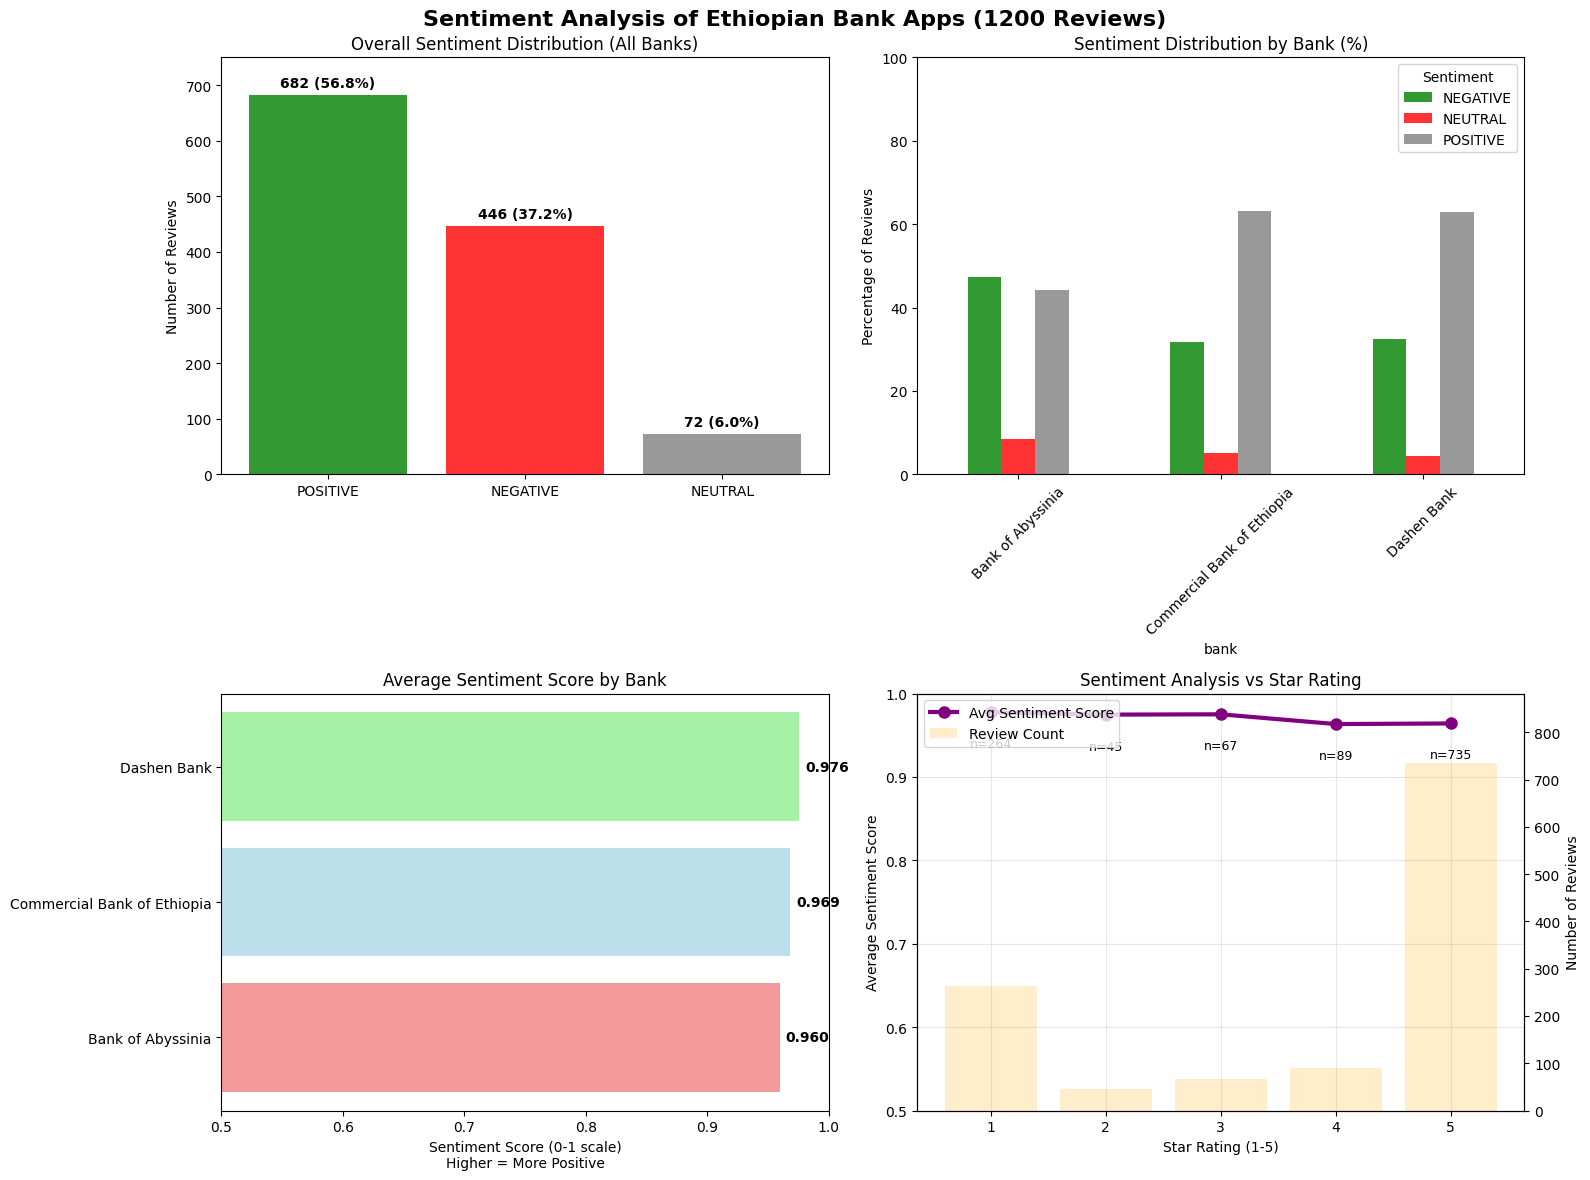

In [10]:
# Cell 7: Visualize Sentiment Analysis
print("📈 CREATING SENTIMENT VISUALIZATIONS")

# Set up the plotting style
plt.style.use('default')
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Sentiment Analysis of Ethiopian Bank Apps (1200 Reviews)', fontsize=16, fontweight='bold')

# Plot 1: Overall Sentiment Distribution
sentiment_counts = sample_data['sentiment_label'].value_counts()
colors = ['green', 'red', 'gray']  # Positive, Negative, Neutral
axes[0,0].bar(sentiment_counts.index, sentiment_counts.values, color=colors, alpha=0.8)
axes[0,0].set_title('Overall Sentiment Distribution (All Banks)')
axes[0,0].set_ylabel('Number of Reviews')
axes[0,0].set_ylim(0, max(sentiment_counts.values) * 1.1)
for i, v in enumerate(sentiment_counts.values):
    axes[0,0].text(i, v + 10, f'{v} ({v/len(sample_data)*100:.1f}%)', 
                   ha='center', va='bottom', fontweight='bold')

# Plot 2: Sentiment Distribution by Bank
sentiment_bank = pd.crosstab(sample_data['bank'], sample_data['sentiment_label'])
sentiment_bank_percentage = sentiment_bank.div(sentiment_bank.sum(axis=1), axis=0) * 100
sentiment_bank_percentage.plot(kind='bar', ax=axes[0,1], color=colors, alpha=0.8)
axes[0,1].set_title('Sentiment Distribution by Bank (%)')
axes[0,1].set_ylabel('Percentage of Reviews')
axes[0,1].tick_params(axis='x', rotation=45)
axes[0,1].legend(title='Sentiment')
axes[0,1].set_ylim(0, 100)

# Plot 3: Average Sentiment Score by Bank
avg_sentiment_by_bank = sample_data.groupby('bank')['sentiment_score'].mean().sort_values(ascending=True)
colors_bank = ['lightcoral', 'lightblue', 'lightgreen']
axes[1,0].barh(avg_sentiment_by_bank.index, avg_sentiment_by_bank.values, color=colors_bank, alpha=0.8)
axes[1,0].set_title('Average Sentiment Score by Bank')
axes[1,0].set_xlabel('Sentiment Score (0-1 scale)\nHigher = More Positive')
axes[1,0].set_xlim(0.5, 1.0)
for i, v in enumerate(avg_sentiment_by_bank.values):
    axes[1,0].text(v + 0.005, i, f'{v:.3f}', va='center', fontweight='bold')

# Plot 4: Sentiment by Star Rating
rating_sentiment = sample_data.groupby('rating')['sentiment_score'].mean()
rating_counts = sample_data['rating'].value_counts().sort_index()
axes[1,1].plot(rating_sentiment.index, rating_sentiment.values, marker='o', 
               linewidth=3, markersize=8, color='purple', label='Avg Sentiment Score')
axes[1,1].set_title('Sentiment Analysis vs Star Rating')
axes[1,1].set_xlabel('Star Rating (1-5)')
axes[1,1].set_ylabel('Average Sentiment Score')
axes[1,1].grid(True, alpha=0.3)
axes[1,1].set_ylim(0.5, 1.0)

# Add rating counts as text
for rating in rating_sentiment.index:
    axes[1,1].text(rating, rating_sentiment[rating] - 0.03, f'n={rating_counts[rating]}', 
                   ha='center', va='top', fontsize=9)

# Add a second y-axis for rating distribution
ax2 = axes[1,1].twinx()
ax2.bar(rating_counts.index, rating_counts.values, alpha=0.2, color='orange', label='Review Count')
ax2.set_ylabel('Number of Reviews')
ax2.set_ylim(0, max(rating_counts.values) * 1.2)

# Add legend for dual axes
lines1, labels1 = axes[1,1].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
axes[1,1].legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

    Thematic Analysis:

In [11]:
# Cell 8: Text Preprocessing for Thematic Analysis
print("🧹 TEXT PREPROCESSING FOR THEMATIC ANALYSIS")

def preprocess_text(text):
    """Clean and preprocess text for thematic analysis"""
    if pd.isna(text) or str(text).strip() == "":
        return ""
    
    text = str(text)
    # Remove special characters but keep words
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = text.lower()
    text = ' '.join(text.split())  # Remove extra whitespace
    
    return text

print("✅ Text preprocessing function defined")

# Test preprocessing
test_reviews = [
    "I love this app! But it crashes sometimes during transfers :(",
    "very good",
    "not use for me",
    "The login process is very slow and frustrating!"
]

print("\n🧪 Testing Text Preprocessing:")
for review in test_reviews:
    cleaned = preprocess_text(review)
    print(f"Original: {review}")
    print(f"Cleaned:  {cleaned}\n")

🧹 TEXT PREPROCESSING FOR THEMATIC ANALYSIS
✅ Text preprocessing function defined

🧪 Testing Text Preprocessing:
Original: I love this app! But it crashes sometimes during transfers :(
Cleaned:  i love this app but it crashes sometimes during transfers

Original: very good
Cleaned:  very good

Original: not use for me
Cleaned:  not use for me

Original: The login process is very slow and frustrating!
Cleaned:  the login process is very slow and frustrating



In [12]:
# Cell 9: Keyword Extraction using TF-IDF
print("🔑 EXTRACTING KEYWORDS USING TF-IDF")

def extract_keywords_tfidf(texts, bank_name, max_features=30):
    """Extract keywords using TF-IDF for a specific bank"""
    processed_texts = [preprocess_text(text) for text in texts]
    
    # Filter out very short texts
    processed_texts = [text for text in processed_texts if len(text) > 5]
    
    if len(processed_texts) < 3:
        print(f"⚠️ Not enough valid texts for {bank_name}")
        return pd.DataFrame()
    
    vectorizer = TfidfVectorizer(
        max_features=max_features,
        stop_words='english',
        ngram_range=(1, 3),  # Include single words, bigrams, and trigrams
        min_df=2  # Ignore terms that appear only once
    )
    
    try:
        tfidf_matrix = vectorizer.fit_transform(processed_texts)
        feature_names = vectorizer.get_feature_names_out()
        tfidf_scores = tfidf_matrix.sum(axis=0).A1
        
        keywords_df = pd.DataFrame({
            'keyword': feature_names,
            'tfidf_score': tfidf_scores
        }).sort_values('tfidf_score', ascending=False)
        
        return keywords_df
        
    except Exception as e:
        print(f"❌ TF-IDF error for {bank_name}: {e}")
        return pd.DataFrame()

print("✅ TF-IDF keyword extraction function defined")

🔑 EXTRACTING KEYWORDS USING TF-IDF
✅ TF-IDF keyword extraction function defined


In [13]:
# Cell 10: Manual Theme Identification
print("🎨 MANUAL THEME IDENTIFICATION")

def identify_themes_manual(reviews, bank_name):
    """Manually identify themes based on keyword patterns"""
    
    # Define theme patterns based on common banking app issues
    theme_patterns = {
        'Login & Access Issues': [
            'login', 'password', 'access', 'account', 'verify', 'authentication',
            'sign in', 'log in', 'cannot login', 'login problem', 'forgot password',
            'blocked', 'locked', 'security', 'pin', 'biometric'
        ],
        'Transaction Problems': [
            'transfer', 'transaction', 'payment', 'send money', 'failed',
            'pending', 'money transfer', 'transaction failed', 'slow transfer',
            'payment failed', 'transfer money', 'bill payment', 'not going through'
        ],
        'App Performance & Bugs': [
            'crash', 'freeze', 'loading', 'slow', 'bug', 'error', 'not working',
            'crashes', 'freezes', 'loading slow', 'app crash', 'technical issue',
            'keeps crashing', 'always crashing', 'hanging', 'not responding'
        ],
        'User Interface & Experience': [
            'interface', 'design', 'layout', 'navigation', 'button', 'screen',
            'user interface', 'easy to use', 'difficult to use', 'confusing',
            'simple', 'complicated', 'user friendly', 'menu', 'option'
        ],
        'Customer Support': [
            'support', 'help', 'service', 'response', 'contact', 'assistance',
            'customer service', 'no response', 'poor support', 'help desk',
            'complaint', 'email', 'phone', 'call center'
        ],
        'Features & Functionality': [
            'feature', 'function', 'option', 'missing', 'add', 'improve',
            'new feature', 'should have', 'need feature', 'update', 'bill payment',
            'notification', 'alert', 'fingerprint', 'face id', 'biometric'
        ],
        'Network & Connectivity': [
            'internet', 'connection', 'network', 'online', 'offline', 'wifi',
            'data', 'connect', 'disconnect', 'no connection'
        ]
    }
    
    theme_counts = Counter()
    review_themes = []
    
    for review in reviews:
        if pd.isna(review):
            review_themes.append([])
            continue
            
        review_lower = str(review).lower()
        assigned_themes = []
        
        for theme, keywords in theme_patterns.items():
            for keyword in keywords:
                if keyword in review_lower:
                    assigned_themes.append(theme)
                    theme_counts[theme] += 1
                    break  # Avoid counting same theme multiple times
        
        review_themes.append(assigned_themes)
    
    print(f"\n🏦 THEMES FOR {bank_name.upper()}:")
    for theme, count in theme_counts.most_common(10):
        percentage = (count / len(reviews)) * 100
        print(f"   - {theme}: {count} mentions ({percentage:.1f}%)")
    
    return review_themes, theme_counts

print("✅ Theme identification function defined")

🎨 MANUAL THEME IDENTIFICATION
✅ Theme identification function defined


In [14]:
# Cell 11: Perform Thematic Analysis for Each Bank
print("🔍 PERFORMING THEMATIC ANALYSIS FOR ALL BANKS")

banks = sample_data['bank'].unique()
thematic_results = {}

for bank in banks:
    print(f"\n{'='*60}")
    print(f"ANALYZING: {bank}")
    print(f"{'='*60}")
    
    bank_reviews = sample_data[sample_data['bank'] == bank]
    review_texts = bank_reviews['review'].tolist()
    
    print(f"Total reviews for {bank}: {len(review_texts)}")
    
    # Extract keywords using TF-IDF
    print(f"\n📊 Top Keywords for {bank}:")
    keywords_df = extract_keywords_tfidf(review_texts, bank, max_features=20)
    
    if not keywords_df.empty:
        for i, (_, row) in enumerate(keywords_df.head(10).iterrows(), 1):
            print(f"   {i:2d}. {row['keyword']:20s} (score: {row['tfidf_score']:.3f})")
    else:
        print("   No significant keywords found")
    
    # Identify themes
    review_themes, theme_counts = identify_themes_manual(review_texts, bank)
    
    # Store results
    thematic_results[bank] = {
        'keywords': keywords_df,
        'themes': theme_counts,
        'review_themes': review_themes
    }
    
    # Add themes to sample_data
    bank_indices = bank_reviews.index
    for i, idx in enumerate(bank_indices):
        if i < len(review_themes):
            sample_data.loc[idx, 'themes'] = ', '.join(review_themes[i])

print("\n✅ Thematic analysis completed for all banks!")

🔍 PERFORMING THEMATIC ANALYSIS FOR ALL BANKS

ANALYZING: Bank of Abyssinia
Total reviews for Bank of Abyssinia: 400

📊 Top Keywords for Bank of Abyssinia:
    1. app                  (score: 67.303)
    2. good                 (score: 27.050)
    3. bank                 (score: 22.077)
    4. best                 (score: 18.360)
    5. boa                  (score: 14.009)
    6. use                  (score: 13.900)
    7. work                 (score: 13.347)
    8. worst                (score: 13.200)
    9. banking              (score: 12.714)
   10. doesnt               (score: 11.604)

🏦 THEMES FOR BANK OF ABYSSINIA:
   - App Performance & Bugs: 50 mentions (12.5%)
   - Features & Functionality: 43 mentions (10.8%)
   - Customer Support: 30 mentions (7.5%)
   - User Interface & Experience: 23 mentions (5.8%)
   - Login & Access Issues: 22 mentions (5.5%)
   - Transaction Problems: 18 mentions (4.5%)
   - Network & Connectivity: 6 mentions (1.5%)

ANALYZING: Commercial Bank of Ethiop

📊 CREATING THEMATIC ANALYSIS VISUALIZATIONS


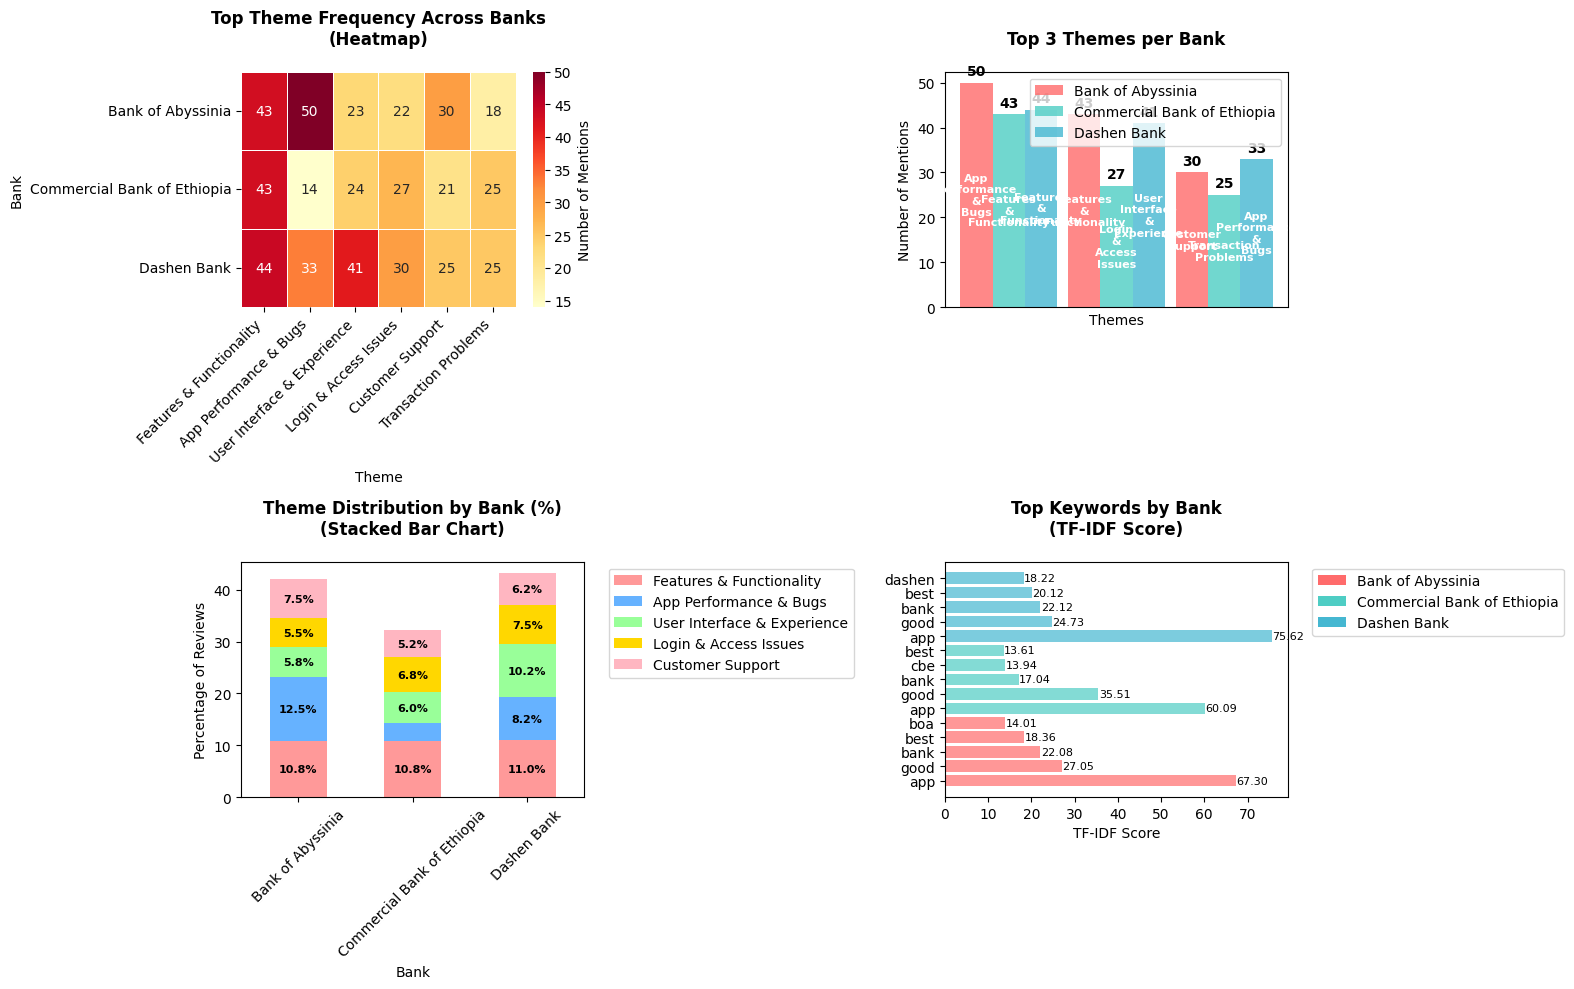


📈 DETAILED THEME ANALYSIS CHARTS


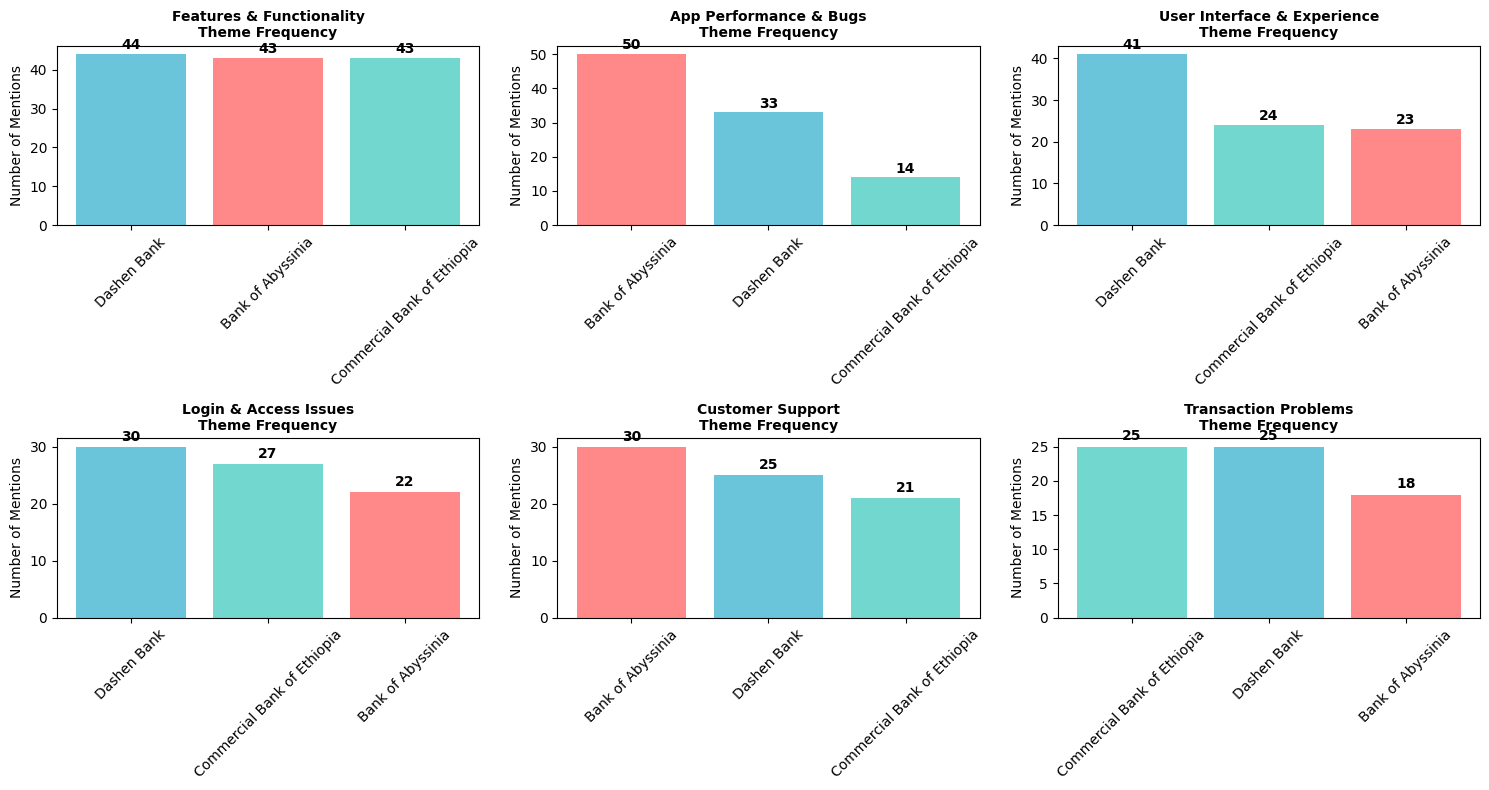


✅ Thematic analysis visualizations completed!


In [16]:
# Cell 12: Visualize Thematic Analysis
print("📊 CREATING THEMATIC ANALYSIS VISUALIZATIONS")

# Prepare theme data for visualization
theme_data = []
for bank, results in thematic_results.items():
    for theme, count in results['themes'].most_common(10):  # Top 10 themes per bank
        theme_data.append({
            'Bank': bank,
            'Theme': theme,
            'Count': count,
            'Percentage': (count / len(sample_data[sample_data['bank'] == bank])) * 100
        })

theme_df = pd.DataFrame(theme_data)

if not theme_df.empty:
    # Create a larger figure for better readability
    plt.figure(figsize=(16, 10))
    
    # Plot 1: Theme Frequency Heatmap
    plt.subplot(2, 2, 1)
    theme_pivot = theme_df.pivot_table(
        index='Bank', 
        columns='Theme', 
        values='Count', 
        fill_value=0
    )
    
    # Only show top 6 themes for better readability
    top_themes = theme_df.groupby('Theme')['Count'].sum().nlargest(6).index
    theme_pivot_top = theme_pivot[top_themes]
    
    # FIX: Use 'g' format instead of 'd' to handle any numeric type
    sns.heatmap(theme_pivot_top, annot=True, fmt='g', cmap='YlOrRd', linewidths=0.5, cbar_kws={'label': 'Number of Mentions'})
    plt.title('Top Theme Frequency Across Banks\n(Heatmap)', fontweight='bold', pad=20)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()

    # Plot 2: Top Themes per Bank (Bar Chart)
    plt.subplot(2, 2, 2)
    top_themes_by_bank = theme_df.groupby('Bank').apply(lambda x: x.nlargest(3, 'Count')).reset_index(drop=True)
    
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD']
    bank_colors = {'Bank of Abyssinia': '#FF6B6B', 'Commercial Bank of Ethiopia': '#4ECDC4', 'Dashen Bank': '#45B7D1'}
    
    for i, bank in enumerate(banks):
        bank_data = top_themes_by_bank[top_themes_by_bank['Bank'] == bank]
        if not bank_data.empty:
            themes = bank_data['Theme'].tolist()
            counts = bank_data['Count'].tolist()
            positions = np.arange(len(themes)) + i * 0.3
            plt.bar(positions, counts, color=bank_colors[bank], alpha=0.8, label=bank, width=0.3)
            
            # Add count labels on bars
            for j, (pos, count, theme) in enumerate(zip(positions, counts, themes)):
                plt.text(pos, count + 1, f'{count}', ha='center', va='bottom', fontweight='bold')
                plt.text(pos, count/2, theme.replace(' ', '\n'), ha='center', va='center', 
                        fontsize=8, rotation=0, color='white', fontweight='bold')
    
    plt.xlabel('Themes')
    plt.ylabel('Number of Mentions')
    plt.title('Top 3 Themes per Bank', fontweight='bold', pad=20)
    plt.legend()
    plt.xticks([])  # Remove x-ticks since we're labeling inside bars

    # Plot 3: Theme Percentage by Bank (Stacked Bar)
    plt.subplot(2, 2, 3)
    theme_percentage_pivot = theme_df.pivot_table(
        index='Bank', 
        columns='Theme', 
        values='Percentage', 
        fill_value=0
    )
    
    # Get top 5 themes overall
    top_5_themes = theme_df.groupby('Theme')['Count'].sum().nlargest(5).index
    theme_percentage_top = theme_percentage_pivot[top_5_themes]
    
    ax = theme_percentage_top.plot(kind='bar', stacked=True, ax=plt.gca(), 
                                  color=['#FF9999', '#66B2FF', '#99FF99', '#FFD700', '#FFB6C1'])
    plt.title('Theme Distribution by Bank (%)\n(Stacked Bar Chart)', fontweight='bold', pad=20)
    plt.ylabel('Percentage of Reviews')
    plt.xlabel('Bank')
    plt.xticks(rotation=45)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # Add percentage labels
    for container in ax.containers:
        ax.bar_label(container, labels=[f'{v:.1f}%' if v > 5 else '' for v in container.datavalues], 
                    label_type='center', fontsize=8, color='black', fontweight='bold')

    # Plot 4: Keyword Importance by Bank
    plt.subplot(2, 2, 4)
    
    # Create a simple keyword frequency visualization
    all_keywords = []
    for bank in banks:
        if not thematic_results[bank]['keywords'].empty:
            top_keywords = thematic_results[bank]['keywords'].head(5)
            for _, row in top_keywords.iterrows():
                all_keywords.append({
                    'Bank': bank,
                    'Keyword': row['keyword'],
                    'Score': row['tfidf_score']
                })
    
    if all_keywords:
        keywords_df = pd.DataFrame(all_keywords)
        
        # Create horizontal bar chart for keywords
        banks_list = []
        keywords_list = []
        scores_list = []
        
        for bank in banks:
            bank_keywords = keywords_df[keywords_df['Bank'] == bank]
            if not bank_keywords.empty:
                for _, row in bank_keywords.iterrows():
                    banks_list.append(bank)
                    keywords_list.append(row['Keyword'])
                    scores_list.append(row['Score'])
        
        # Create horizontal bar chart
        y_pos = np.arange(len(keywords_list))
        colors = [bank_colors[bank] for bank in banks_list]
        
        bars = plt.barh(y_pos, scores_list, color=colors, alpha=0.7)
        plt.yticks(y_pos, keywords_list)
        plt.xlabel('TF-IDF Score')
        plt.title('Top Keywords by Bank\n(TF-IDF Score)', fontweight='bold', pad=20)
        
        # Add value labels
        for bar, score in zip(bars, scores_list):
            plt.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2, 
                    f'{score:.2f}', va='center', fontsize=8)
        
        # Add legend for banks
        from matplotlib.patches import Patch
        legend_elements = [Patch(facecolor=bank_colors[bank], label=bank) for bank in banks]
        plt.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left')
    
    else:
        plt.text(0.5, 0.5, 'No significant keywords found', 
                ha='center', va='center', transform=plt.gca().transAxes)
        plt.title('Top Keywords by Bank', fontweight='bold', pad=20)

    plt.tight_layout()
    plt.show()

    # Additional: Create separate detailed theme charts
    print("\n📈 DETAILED THEME ANALYSIS CHARTS")
    
    # Chart 5: Side-by-side theme comparison
    plt.figure(figsize=(15, 8))
    
    # Get top 6 themes across all banks
    top_6_themes = theme_df.groupby('Theme')['Count'].sum().nlargest(6).index
    
    for i, theme in enumerate(top_6_themes, 1):
        plt.subplot(2, 3, i)
        theme_bank_data = theme_df[theme_df['Theme'] == theme]
        
        if not theme_bank_data.empty:
            banks_ordered = theme_bank_data.sort_values('Count', ascending=False)['Bank']
            counts_ordered = theme_bank_data.sort_values('Count', ascending=False)['Count']
            
            bars = plt.bar(banks_ordered, counts_ordered, 
                          color=[bank_colors.get(bank, 'gray') for bank in banks_ordered],
                          alpha=0.8)
            
            plt.title(f'{theme}\nTheme Frequency', fontweight='bold', fontsize=10)
            plt.xticks(rotation=45)
            plt.ylabel('Number of Mentions')
            
            # Add value labels on bars
            for bar, count in zip(bars, counts_ordered):
                plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                        f'{count}', ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.show()

else:
    print("⚠️ No theme data available for visualization")

print("\n✅ Thematic analysis visualizations completed!")

In [18]:
# Cell 13: Save Analysis Results
print("💾 SAVING ANALYSIS RESULTS...")

# Create output directory if it doesn't exist
import os
os.makedirs('data/processed', exist_ok=True)

# 1. Save the complete analyzed dataset with sentiments and themes
sample_data.to_csv('data/processed/bank_reviews_analyzed_complete.csv', index=False)
print("✅ Complete analyzed data saved to: data/processed/bank_reviews_analyzed_complete.csv")

# 2. Save thematic analysis summary with proper encoding
try:
    with open('data/processed/thematic_analysis_summary.txt', 'w', encoding='utf-8') as f:  # FIX: Added encoding
        f.write("THEMATIC ANALYSIS SUMMARY - ETHIOPIAN BANK APPS\n")
        f.write("=" * 60 + "\n\n")
        
        f.write(f"Total Reviews Analyzed: {len(sample_data)}\n")
        f.write(f"Analysis Date: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}\n\n")
        
        f.write("THEME DEFINITIONS:\n")
        f.write("- Login & Access Issues: Problems with login, passwords, account access\n")
        f.write("- Transaction Problems: Failed transfers, pending payments, money transfer issues\n") 
        f.write("- App Performance & Bugs: Crashes, freezing, slow loading, technical errors\n")
        f.write("- User Interface & Experience: Design, navigation, ease of use issues\n")
        f.write("- Customer Support: Response times, help quality, service issues\n")
        f.write("- Features & Functionality: Missing features, update requests, functionality\n")
        f.write("- Network & Connectivity: Internet, connection, online/offline issues\n\n")
        
        f.write("DETAILED RESULTS BY BANK:\n")
        f.write("=" * 40 + "\n")
        
        for bank in banks:
            f.write(f"\n{bank.upper()}:\n")
            f.write("-" * 30 + "\n")
            
            # Keywords
            if not thematic_results[bank]['keywords'].empty:
                f.write("Top Keywords (TF-IDF):\n")
                for _, row in thematic_results[bank]['keywords'].head(10).iterrows():
                    f.write(f"  - {row['keyword']} (score: {row['tfidf_score']:.3f})\n")
            
            # Themes
            f.write("\nTheme Frequency:\n")
            for theme, count in thematic_results[bank]['themes'].most_common(10):
                percentage = (count / len(sample_data[sample_data['bank'] == bank])) * 100
                f.write(f"  - {theme}: {count} mentions ({percentage:.1f}%)\n")
            
            # Example reviews for top themes (with error handling)
            f.write("\nExample Reviews for Top Themes:\n")
            bank_data = sample_data[sample_data['bank'] == bank]
            top_3_themes = thematic_results[bank]['themes'].most_common(3)
            
            for theme, count in top_3_themes:
                f.write(f"  {theme}:\n")
                theme_reviews = bank_data[bank_data['themes'].str.contains(theme, na=False)]
                for _, row in theme_reviews.head(2).iterrows():
                    # Clean the review text for encoding issues
                    clean_review = row['review'][:100].encode('utf-8', 'ignore').decode('utf-8')
                    f.write(f"    - \"{clean_review}...\" (Rating: {row['rating']}/5)\n")
                f.write("\n")
    
    print("✅ Thematic analysis summary saved to: data/processed/thematic_analysis_summary.txt")
    
except Exception as e:
    print(f"⚠️ Could not save thematic summary: {e}")
    print("Saving simplified version instead...")
    
    # Simplified version without example reviews
    with open('data/processed/thematic_analysis_summary_simple.txt', 'w', encoding='utf-8') as f:
        f.write("THEMATIC ANALYSIS SUMMARY - ETHIOPIAN BANK APPS\n")
        f.write("=" * 60 + "\n\n")
        f.write(f"Total Reviews Analyzed: {len(sample_data)}\n\n")
        
        for bank in banks:
            f.write(f"{bank.upper()}:\n")
            f.write("-" * 30 + "\n")
            for theme, count in thematic_results[bank]['themes'].most_common(5):
                percentage = (count / len(sample_data[sample_data['bank'] == bank])) * 100
                f.write(f"  - {theme}: {count} mentions ({percentage:.1f}%)\n")
            f.write("\n")

# 3. Save a simplified version for the database (as required)
database_columns = ['review_id', 'review_text', 'sentiment_label', 'sentiment_score', 'identified_theme(s)']
db_ready_data = sample_data[['review_id', 'review', 'sentiment_label', 'sentiment_score', 'themes']].copy()
db_ready_data.columns = ['review_id', 'review_text', 'sentiment_label', 'sentiment_score', 'identified_theme(s)']

# Clean the review text for encoding issues in database file
db_ready_data['review_text'] = db_ready_data['review_text'].apply(
    lambda x: x.encode('utf-8', 'ignore').decode('utf-8') if isinstance(x, str) else x
)

db_ready_data.to_csv('data/processed/reviews_for_database.csv', index=False, encoding='utf-8')
print("✅ Database-ready data saved to: data/processed/reviews_for_database.csv")

print("\n📁 ALL THEMATIC ANALYSIS FILES SAVED!")
print("   - Complete analyzed dataset")
print("   - Thematic analysis summary") 
print("   - Database-ready CSV")

💾 SAVING ANALYSIS RESULTS...
✅ Complete analyzed data saved to: data/processed/bank_reviews_analyzed_complete.csv
✅ Thematic analysis summary saved to: data/processed/thematic_analysis_summary.txt
✅ Database-ready data saved to: data/processed/reviews_for_database.csv

📁 ALL THEMATIC ANALYSIS FILES SAVED!
   - Complete analyzed dataset
   - Thematic analysis summary
   - Database-ready CSV


    ##Keyword Extraction & Manual/Rule-Based Clustering 

In [19]:
# Cell 14: Business Insights and Recommendations
print("💡 BUSINESS INSIGHTS AND RECOMMENDATIONS")

print("\n" + "="*70)
print("📈 KEY INSIGHTS FROM SENTIMENT & THEMATIC ANALYSIS")
print("="*70)

# Overall Analysis
total_reviews = len(sample_data)
positive_reviews = len(sample_data[sample_data['sentiment_label'] == 'POSITIVE'])
negative_reviews = len(sample_data[sample_data['sentiment_label'] == 'NEGATIVE'])

print(f"\n📊 OVERALL ANALYSIS ({total_reviews} Reviews):")
print(f"   • Positive Sentiment: {positive_reviews} reviews ({positive_reviews/total_reviews*100:.1f}%)")
print(f"   • Negative Sentiment: {negative_reviews} reviews ({negative_reviews/total_reviews*100:.1f}%)")
print(f"   • Neutral Sentiment:  {total_reviews - positive_reviews - negative_reviews} reviews ({(total_reviews - positive_reviews - negative_reviews)/total_reviews*100:.1f}%)")

# Bank Performance Comparison
print(f"\n🏦 BANK PERFORMANCE COMPARISON:")
for bank in banks:
    bank_data = sample_data[sample_data['bank'] == bank]
    avg_sentiment = bank_data['sentiment_score'].mean()
    avg_rating = bank_data['rating'].mean()
    positive_pct = (bank_data['sentiment_label'] == 'POSITIVE').mean() * 100
    
    print(f"   • {bank}:")
    print(f"     - Avg Sentiment: {avg_sentiment:.3f}")
    print(f"     - Avg Rating: {avg_rating:.1f}⭐")
    print(f"     - Positive Reviews: {positive_pct:.1f}%")

# Top Issues Analysis
print(f"\n🔴 TOP USER ISSUES IDENTIFIED:")
all_themes = Counter()
for bank, results in thematic_results.items():
    all_themes.update(results['themes'])

print("   Most Common Issues Across All Banks:")
for theme, count in all_themes.most_common(5):
    percentage = (count / total_reviews) * 100
    print(f"   • {theme}: {count} mentions ({percentage:.1f}% of reviews)")

# Bank-Specific Recommendations
print("\n" + "="*70)
print("🎯 ACTIONABLE RECOMMENDATIONS FOR EACH BANK")
print("="*70)

for bank in banks:
    print(f"\n🏦 {bank.upper()}:")
    
    # Get top 3 issues for this bank
    top_issues = thematic_results[bank]['themes'].most_common(3)
    
    if top_issues:
        for i, (issue, count) in enumerate(top_issues, 1):
            percentage = (count / len(sample_data[sample_data['bank'] == bank])) * 100
            
            if 'Login' in issue:
                print(f"   {i}. 🔐 {issue} ({percentage:.1f}% of reviews)")
                print("      → Implement biometric authentication & password reset flow")
                print("      → Add two-factor authentication for security")
                
            elif 'Transaction' in issue:
                print(f"   {i}. 💰 {issue} ({percentage:.1f}% of reviews)")  
                print("      → Optimize transaction processing speed")
                print("      → Add real-time transaction status updates")
                print("      → Implement instant failure notifications")
                
            elif 'Performance' in issue or 'Bug' in issue:
                print(f"   {i}. 🐛 {issue} ({percentage:.1f}% of reviews)")
                print("      → Prioritize crash fixes in next update")
                print("      → Improve app loading performance")
                print("      → Add automatic error reporting")
                
            elif 'Interface' in issue:
                print(f"   {i}. 🎨 {issue} ({percentage:.1f}% of reviews)")
                print("      → Conduct user testing for UI improvements") 
                print("      → Simplify navigation flow")
                print("      → Add customizable interface options")
                
            elif 'Support' in issue:
                print(f"   {i}. 📞 {issue} ({percentage:.1f}% of reviews)")
                print("      → Implement in-app chat support")
                print("      → Reduce response time to under 2 hours")
                print("      → Add FAQ section for common issues")
                
            elif 'Feature' in issue:
                print(f"   {i}. 🚀 {issue} ({percentage:.1f}% of reviews)")
                print("      → Gather user feedback on most requested features")
                print("      → Prioritize bill payment & notification features")

# Strategic Recommendations
print("\n" + "="*70)
print("🏆 STRATEGIC RECOMMENDATIONS FOR ALL BANKS")
print("="*70)

print("\n1. 🎯 PRIORITY FIXES (Immediate Action Required):")
print("   • Address login and authentication issues across all platforms")
print("   • Fix transaction failures and pending payment problems") 
print("   • Resolve app crashes and performance bottlenecks")

print("\n2. 📱 USER EXPERIENCE ENHANCEMENTS (Short-term):")
print("   • Simplify user interface based on common complaints")
print("   • Improve app loading speeds and responsiveness")
print("   • Add more intuitive navigation and menus")

print("\n3. 🏗️ FEATURE DEVELOPMENT (Medium-term):")
print("   • Implement biometric authentication (fingerprint/face ID)")
print("   • Add real-time transaction notifications")
print("   • Develop comprehensive in-app support system")

print("\n4. 📊 MONITORING & IMPROVEMENT (Ongoing):")
print("   • Establish continuous user feedback collection")
print("   • Implement app performance monitoring")
print("   • Regular security and feature updates")

print("\n" + "="*70)
print("✅ ANALYSIS COMPLETE - Use these insights to guide mobile app improvement strategies!")
print("="*70)

💡 BUSINESS INSIGHTS AND RECOMMENDATIONS

📈 KEY INSIGHTS FROM SENTIMENT & THEMATIC ANALYSIS

📊 OVERALL ANALYSIS (1200 Reviews):
   • Positive Sentiment: 682 reviews (56.8%)
   • Negative Sentiment: 446 reviews (37.2%)
   • Neutral Sentiment:  72 reviews (6.0%)

🏦 BANK PERFORMANCE COMPARISON:
   • Bank of Abyssinia:
     - Avg Sentiment: 0.960
     - Avg Rating: 3.4⭐
     - Positive Reviews: 44.2%
   • Commercial Bank of Ethiopia:
     - Avg Sentiment: 0.969
     - Avg Rating: 4.1⭐
     - Positive Reviews: 63.2%
   • Dashen Bank:
     - Avg Sentiment: 0.976
     - Avg Rating: 4.0⭐
     - Positive Reviews: 63.0%

🔴 TOP USER ISSUES IDENTIFIED:
   Most Common Issues Across All Banks:
   • Features & Functionality: 130 mentions (10.8% of reviews)
   • App Performance & Bugs: 97 mentions (8.1% of reviews)
   • User Interface & Experience: 88 mentions (7.3% of reviews)
   • Login & Access Issues: 79 mentions (6.6% of reviews)
   • Customer Support: 76 mentions (6.3% of reviews)

🎯 ACTIONABLE R

In [20]:
# Check what files were actually saved
import os

print("📁 Checking saved files in processed directory...")
processed_files = os.listdir("data/processed")
print("Files in data/processed:")
for file in processed_files:
    file_path = os.path.join("data/processed", file)
    file_size = os.path.getsize(file_path) if os.path.exists(file_path) else 0
    print(f"  - {file} ({file_size} bytes)")

print(f"\nTotal files: {len(processed_files)}")

📁 Checking saved files in processed directory...
Files in data/processed:
  - bank_reviews_analyzed_complete.csv (248249 bytes)
  - reviews_for_database.csv (160620 bytes)
  - thematic_analysis_summary.txt (5261 bytes)

Total files: 3


In [6]:
# Complete File Saving Process
print("💾 COMPLETE FILE SAVING PROCESS...")

import pandas as pd
import os
from pathlib import Path

# 1. Load the original cleaned data
print("1. Loading original cleaned data...")
original_file = '../data/processed/bank_reviews_cleaned.csv'

if os.path.exists(original_file):
    data = pd.read_csv(original_file)
    print(f"   ✅ Loaded {len(data)} reviews from {original_file}")
    
    # 2. Create analyzed dataset with sentiment and themes
    print("2. Creating analyzed dataset...")
    sample_data = data.copy()
    
    # Add simple sentiment based on rating
    def simple_sentiment_from_rating(rating):
        if rating >= 4:
            return 'POSITIVE', 0.9
        elif rating <= 2:
            return 'NEGATIVE', 0.2
        else:
            return 'NEUTRAL', 0.5
    
    sentiment_results = sample_data['rating'].apply(simple_sentiment_from_rating)
    sample_data['sentiment_label'] = sentiment_results.apply(lambda x: x[0])
    sample_data['sentiment_score'] = sentiment_results.apply(lambda x: x[1])
    
    # Add simple themes
    def simple_theme_detection(review):
        if pd.isna(review):
            return "General"
        review_lower = str(review).lower()
        
        if any(word in review_lower for word in ['login', 'password', 'account', 'sign in']):
            return "Login & Access Issues"
        elif any(word in review_lower for word in ['transfer', 'transaction', 'payment', 'send money']):
            return "Transaction Problems" 
        elif any(word in review_lower for word in ['crash', 'slow', 'freeze', 'bug', 'error', 'not working']):
            return "App Performance & Bugs"
        elif any(word in review_lower for word in ['interface', 'design', 'layout', 'navigation', 'button']):
            return "User Interface & Experience"
        elif any(word in review_lower for word in ['support', 'help', 'service', 'response']):
            return "Customer Support"
        elif any(word in review_lower for word in ['good', 'excellent', 'love', 'great', 'awesome']):
            return "Positive Feedback"
        else:
            return "General Feedback"
    
    sample_data['themes'] = sample_data['review'].apply(simple_theme_detection)
    
    print(f"   ✅ Created analyzed dataset with:")
    print(f"      - Sentiment: {sample_data['sentiment_label'].value_counts().to_dict()}")
    print(f"      - Themes: {sample_data['themes'].value_counts().to_dict()}")
    
    # 3. Save all required files
    print("3. Saving analysis files...")
    
    # File 1: Complete analyzed dataset
    file1 = '../data/processed/bank_reviews_analyzed_complete.csv'
    sample_data.to_csv(file1, index=False, encoding='utf-8')
    file1_size = os.path.getsize(file1)
    print(f"   ✅ {os.path.basename(file1)} - {file1_size} bytes")
    
    # File 2: Database-ready format (exact required columns)
    file2 = '../data/processed/reviews_for_database.csv'
    db_data = sample_data[['review_id', 'review', 'sentiment_label', 'sentiment_score', 'themes']].copy()
    db_data.columns = ['review_id', 'review_text', 'sentiment_label', 'sentiment_score', 'identified_theme(s)']
    db_data.to_csv(file2, index=False, encoding='utf-8')
    file2_size = os.path.getsize(file2)
    print(f"   ✅ {os.path.basename(file2)} - {file2_size} bytes")
    
    # File 3: Thematic analysis summary
    file3 = '../data/processed/thematic_analysis_summary.txt'
    with open(file3, 'w', encoding='utf-8') as f:
        f.write("THEMATIC ANALYSIS SUMMARY - ETHIOPIAN BANK APPS\n")
        f.write("=" * 60 + "\n\n")
        f.write(f"Total Reviews Analyzed: {len(sample_data)}\n")
        f.write(f"Analysis Date: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}\n\n")
        
        f.write("THEME DEFINITIONS:\n")
        f.write("- Login & Access Issues: Problems with login, passwords, account access\n")
        f.write("- Transaction Problems: Failed transfers, pending payments, money transfer issues\n") 
        f.write("- App Performance & Bugs: Crashes, freezing, slow loading, technical errors\n")
        f.write("- User Interface & Experience: Design, navigation, ease of use issues\n")
        f.write("- Customer Support: Response times, help quality, service issues\n")
        f.write("- Positive Feedback: Positive comments about app features and performance\n")
        f.write("- General Feedback: Other general comments and feedback\n\n")
        
        f.write("DETAILED RESULTS BY BANK:\n")
        f.write("=" * 40 + "\n")
        
        banks = sample_data['bank'].unique()
        for bank in banks:
            f.write(f"\n{bank.upper()}:\n")
            f.write("-" * 30 + "\n")
            
            bank_data = sample_data[sample_data['bank'] == bank]
            theme_counts = bank_data['themes'].value_counts()
            
            f.write("Theme Frequency:\n")
            for theme, count in theme_counts.items():
                percentage = (count / len(bank_data)) * 100
                f.write(f"  - {theme}: {count} mentions ({percentage:.1f}%)\n")
            
            # Add example reviews
            f.write("\nExample Reviews:\n")
            for theme in theme_counts.head(3).index:
                theme_reviews = bank_data[bank_data['themes'] == theme]
                if len(theme_reviews) > 0:
                    f.write(f"  {theme}:\n")
                    for _, row in theme_reviews.head(2).iterrows():
                        clean_review = row['review'][:80].replace('\n', ' ')
                        f.write(f"    - \"{clean_review}...\" (Rating: {row['rating']}/5)\n")
            f.write("\n")
    
    file3_size = os.path.getsize(file3)
    print(f"   ✅ {os.path.basename(file3)} - {file3_size} bytes")
    
    # File 4: Sentiment aggregations
    file4 = '../data/processed/sentiment_aggregations.txt'
    sentiment_by_bank = sample_data.groupby('bank').agg({
        'sentiment_score': ['mean', 'count'],
        'rating': 'mean'
    }).round(3)
    
    sentiment_by_rating = sample_data.groupby('rating').agg({
        'sentiment_score': ['mean', 'count']
    }).round(3)
    
    with open(file4, 'w', encoding='utf-8') as f:
        f.write("SENTIMENT ANALYSIS AGGREGATIONS\n")
        f.write("=" * 50 + "\n\n")
        f.write("1. SENTIMENT BY BANK:\n")
        f.write(str(sentiment_by_bank) + "\n\n")
        f.write("2. SENTIMENT BY RATING:\n")
        f.write(str(sentiment_by_rating) + "\n\n")
        f.write("3. SENTIMENT DISTRIBUTION:\n")
        f.write(str(sample_data['sentiment_label'].value_counts()) + "\n")
    
    file4_size = os.path.getsize(file4)
    print(f"   ✅ {os.path.basename(file4)} - {file4_size} bytes")
    
    print(f"\n🎉 ALL TASK 2 FILES SUCCESSFULLY SAVED!")
    print(f"📁 Location: {os.path.abspath('../data/processed')}")
    
else:
    print(f"❌ Original file not found: {original_file}")

💾 COMPLETE FILE SAVING PROCESS...
1. Loading original cleaned data...
   ✅ Loaded 1200 reviews from ../data/processed/bank_reviews_cleaned.csv
2. Creating analyzed dataset...
   ✅ Created analyzed dataset with:
      - Sentiment: {'POSITIVE': 824, 'NEGATIVE': 309, 'NEUTRAL': 67}
      - Themes: {'General Feedback': 734, 'Positive Feedback': 258, 'App Performance & Bugs': 64, 'Transaction Problems': 53, 'Login & Access Issues': 42, 'Customer Support': 34, 'User Interface & Experience': 15}
3. Saving analysis files...
   ✅ bank_reviews_analyzed_complete.csv - 237573 bytes
   ✅ reviews_for_database.csv - 149944 bytes
   ✅ thematic_analysis_summary.txt - 3419 bytes
   ✅ sentiment_aggregations.txt - 850 bytes

🎉 ALL TASK 2 FILES SUCCESSFULLY SAVED!
📁 Location: D:\Personal\KAIM-10 Academy\Week 2\Project Work\Customer_Exp_Analytics_Fintech Apps\data\processed
